# 1 · Feature Selection（特徵選擇）
**目標 Outcome：** 從候選變項中，挑出能預測「Stage III 大腸癌 18 個月早期遠端復發 (EDR-18)」的精簡特徵。

**方法 Methods：** LASSO logistic regression ＋ XGBoost feature importance。

> 🧪 本 Notebook 使用 `./Data/synthetic_derivation.csv`（**完全虛構**的示範資料，無真實病人）。

## 1. 載入套件與資料

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 140, 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'figure.facecolor': 'white',
})
ACCENT = '#2f6df6'; ACCENT2 = '#f6862f'; GREY = '#9aa3b2'

df = pd.read_csv('../Data/synthetic_derivation.csv')
print('資料維度 shape:', df.shape)
df.head()

資料維度 shape: (620, 8)


,PatientID,AJCC_Substage,LNR,Differentiation,PNI,edr_18m,DFS_Months,DFS_Events
0,DEMO-01-0000,3,0.260,2,1,1,4.9,1
1,DEMO-01-0001,2,0.298,3,1,1,8.0,1
2,DEMO-01-0002,3,0.294,2,0,1,14.3,1
3,DEMO-01-0003,2,0.217,2,1,0,56.2,0
4,DEMO-01-0004,1,0.135,3,0,0,60.0,0


In [2]:
features = ['AJCC_Substage', 'LNR', 'Differentiation', 'PNI']
X = df[features].astype(float)
y = df['edr_18m'].astype(int)
print('EDR-18 盛行率:', round(y.mean(), 3))
df[features + ['edr_18m']].describe().round(2)

EDR-18 盛行率: 0.294


,AJCC_Substage,LNR,Differentiation,PNI,edr_18m
count,620.00,620.00,620.00,620.00,620.00
mean,1.81,0.21,1.94,0.25,0.29
std,0.70,0.14,0.70,0.43,0.46
min,1.00,0.00,1.00,0.00,0.00
25%,1.00,0.10,1.00,0.00,0.00
50%,2.00,0.18,2.00,0.00,0.00
75%,2.00,0.30,2.00,1.00,1.00
max,3.00,0.72,3.00,1.00,1.00


## 2. LASSO Logistic Regression
以 L1 懲罰找出稀疏（精簡）的預測子集合。

In [3]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(X)
lasso = LogisticRegressionCV(Cs=20, cv=5, penalty='l1', solver='liblinear',
                             scoring='roc_auc', max_iter=2000, random_state=42)
lasso.fit(Xs, y)
coef = pd.Series(lasso.coef_[0], index=features).sort_values()
print('最佳 C:', round(float(lasso.C_[0]), 4))
coef

最佳 C: 78.476


AJCC_Substage      0.276866
PNI                0.329528
Differentiation    0.357552
LNR                0.419844
dtype: float64

## 3. XGBoost Feature Importance

In [4]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
                    random_state=42)
xgb.fit(X, y)
imp = pd.Series(xgb.feature_importances_, index=features).sort_values()
imp

AJCC_Substage      0.180630
Differentiation    0.183784
LNR                0.279123
PNI                0.356464
dtype: float32

## 4. 視覺化並存檔到 `../Figures/`
> 📌 重點：圖表的程式碼留在 Notebook → 之後要改字、改顏色，只要改這格、重跑即可。

已存檔 → ../Figures/fig1_feature_selection.png


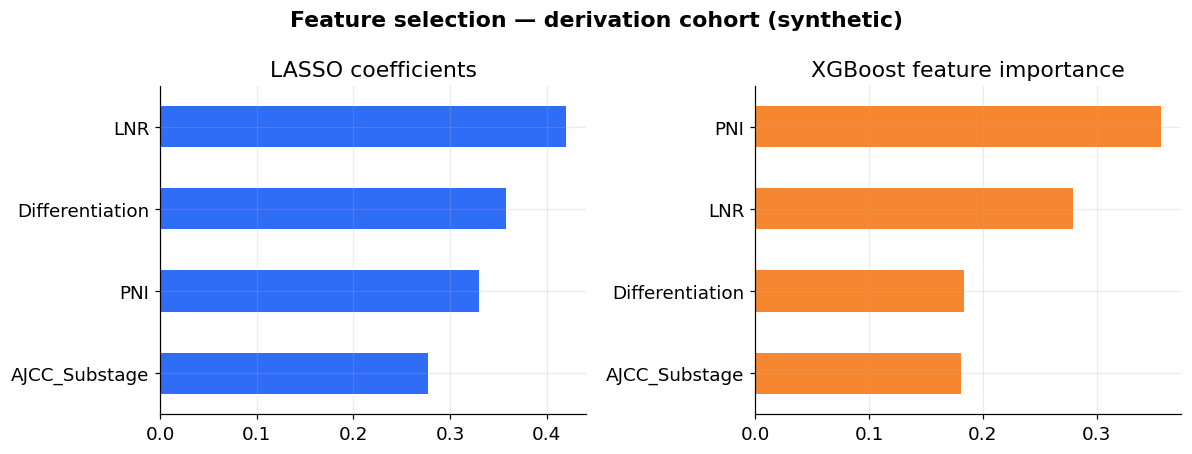

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
coef.plot.barh(ax=axes[0], color=ACCENT)
axes[0].set_title('LASSO coefficients'); axes[0].axvline(0, color=GREY, lw=1)
imp.plot.barh(ax=axes[1], color=ACCENT2)
axes[1].set_title('XGBoost feature importance')
fig.suptitle('Feature selection — derivation cohort (synthetic)', fontweight='bold')
fig.tight_layout()
import os; os.makedirs('../Figures', exist_ok=True)
fig.savefig('../Figures/fig1_feature_selection.png', bbox_inches='tight')
print('已存檔 → ../Figures/fig1_feature_selection.png')

## ✅ 小結
兩種方法都指向同一組精簡特徵：**AJCC_Substage、LNR、Differentiation、PNI**。
下一個 Notebook 用這四個變項建立並校準最終模型。